<a href="https://colab.research.google.com/github/NielsRogge/Transformers-Tutorials/blob/master/SAM3-LiteText/SAM_3_Lite_Text_vs_SAM_3_for_prompt_based_image_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Set-up environment

We start by installing the Transformers library from Github, as [SAM-3 Lite-Text](https://huggingface.co/docs/transformers/main/en/model_doc/sam3_lite_text) is brand new at the time of writing. It will be in the next [PyPi release](https://pypi.org/project/transformers/) of Transformers.

SAM-3 Lite-Text replaces 88% of the parameters of the heavy text encoder of Meta's [SAM-3](https://huggingface.co/docs/transformers/main/en/model_doc/sam3) while roughly retaining the same performance. This is done by treating the smaller text encoders (based on MobileCLIP) as students, which learn from the original text encoder which serves as teacher. This process is called knowledge distillation, originally introduced by Hinton et al in [this paper](https://arxiv.org/abs/1503.02531).

In [1]:
!pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Load models

We start by loading both SAM-3 and the new SAM-3 Lite-Text models from the hub. Do note that the authors of SAM-3 Lite-Text have released 3 different checkpoints on the hub which use different MobileCLIP students to replace the text encoder of SAM-3. Find them [here](https://huggingface.co/models?other=sam3_lite_text).

For details on their performance differences, refer to the [original paper](https://huggingface.co/papers/2602.12173).

As Meta's SAM-3 has [gated access](https://huggingface.co/facebook/sam3) on the hub, we need to provide our HF token (once you got approval), which we set as an environment variable below.

In [25]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

When loading both models, we put them on the GPU by adding `.to(device)`. Do note that, as I'm running this on the free version of Google Colab which only provides an NVIDIA T4 GPU, we cannot set the torch dtype to bfloat 16 (by setting `dtype=torch.bfloat16` in the `from_pretrained` method), which would reduce the memory requirements. Feel free to do so if your GPU supports it.

In [14]:
from transformers import Sam3Processor, Sam3Model, AutoModel
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

SAM3_ID = "facebook/sam3"
LITE_ID = "yonigozlan/sam3-litetext-s0"

model = Sam3Model.from_pretrained(SAM3_ID).to(device)
processor = Sam3Processor.from_pretrained(SAM3_ID)

lite_model = AutoModel.from_pretrained(LITE_ID).to(device)
lite_processor = Sam3Processor.from_pretrained(LITE_ID)

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1204 [00:00<?, ?it/s]

## Process image + text prompt using both models

Next, we can send the same image and text prompt through both SAM-3 and its lighter SAM-3 Lite-Text. Usage of both models is identical in Transformers, we only need to use the appropriate model and processor. Hence, we wrap inference in a function which can be easily reused.

We add the `torch.no_grad()` annotator as we don't need to compute any gradients here (as we're doing inference rather than training). This reduces memory requirements.

In [33]:
import torch
from PIL import Image
from transformers.image_utils import load_image

@torch.no_grad()
def inference(model, processor, image: Image.Image, text_prompt: str) -> dict:
    # Prepare image and text prompt
    inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(device)

    # Forward pass
    outputs = model(**inputs)

    # Post-process results
    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=0.5,
        mask_threshold=0.5,
        target_sizes=inputs.get("original_sizes").tolist()
    )[0]

    return results

# Load image
image_url = "http://images.cocodataset.org/val2017/000000077595.jpg"
image = load_image(image_url)

# Process with both models
results = inference(model, processor, image, "ear")
lite_results = inference(lite_model, lite_processor, image, "ear")
print(f"SAM-3 found {len(results['masks'])} objects")
print(f"SAM-3 Lite-Text found {len(lite_results['masks'])} objects")

# Results contain:
# - masks: Binary masks resized to original image size
# - boxes: Bounding boxes in absolute pixel coordinates (xyxy format)
# - scores: Confidence scores

SAM-3 found 2 objects
SAM-3 Lite-Text found 2 objects


## Visualize results

Finally, we can plot the results so we can visually compare the results!

Visualizing SAM-3 Results:


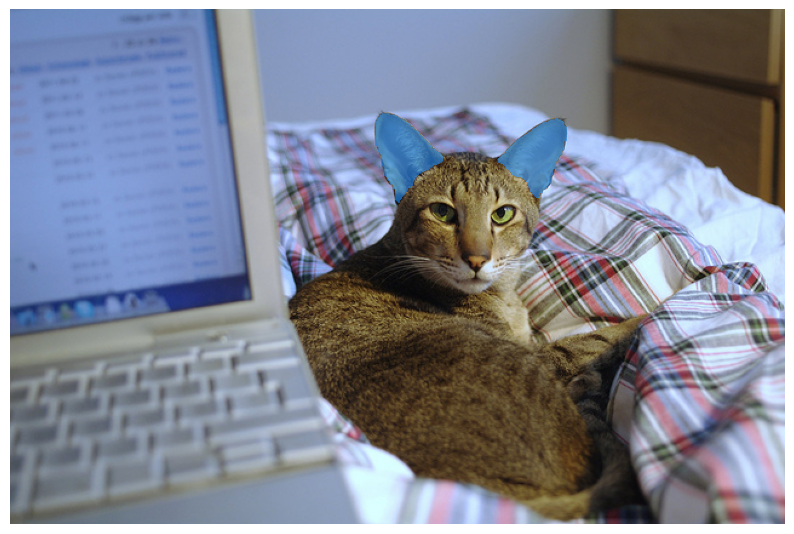

Visualizing SAM-3 Lite-Text Results:


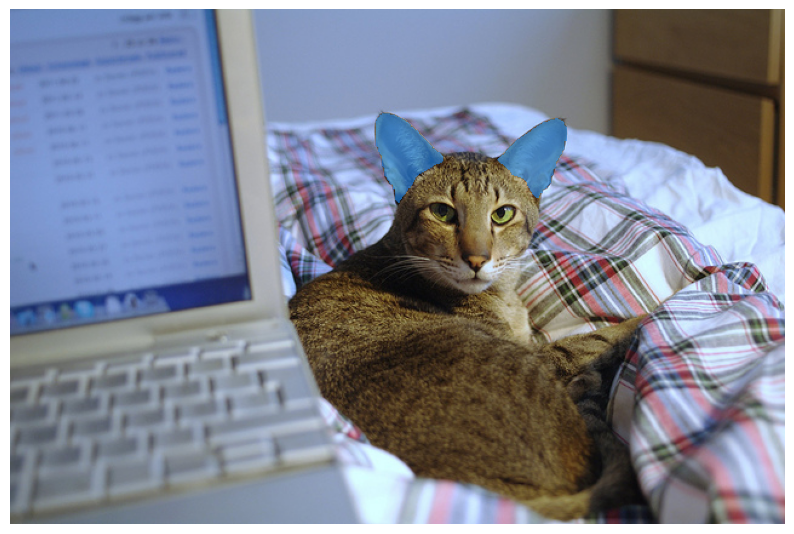

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def visualize_masks(image, segmentation_results):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    for mask in segmentation_results['masks']:
        show_mask(mask.cpu().numpy(), plt.gca(), random_color=False)
    plt.axis('off')
    plt.show()

# Example: Visualize Lite-Text results
print("Visualizing SAM-3 Results:")
visualize_masks(image, results)
print("Visualizing SAM-3 Lite-Text Results:")
visualize_masks(image, lite_results)

The results look pretty identical!

### Memory Comparison

Let's quantify the difference in model size by calculating the number of parameters and the estimated GPU memory required for the weights.

In [34]:
def get_model_size(model):
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    size_all_mb = (param_size + buffer_size) / 1024**2
    return size_all_mb, sum(p.numel() for p in model.parameters())

sam3_mb, sam3_params = get_model_size(model)
lite_mb, lite_params = get_model_size(lite_model)

print(f"SAM-3 Size: {sam3_mb:.2f} MB ({sam3_params/1e6:.2f}M parameters)")
print(f"SAM-3 Lite-Text Size: {lite_mb:.2f} MB ({lite_params/1e6:.2f}M parameters)")
print(f"Reduction: {(1 - lite_mb/sam3_mb)*100:.2f}%")

SAM-3 Size: 3223.78 MB (840.38M parameters)
SAM-3 Lite-Text Size: 2036.86 MB (529.22M parameters)
Reduction: 36.82%


### Text Encoder Comparison

SAM-3 Lite-Text achieves its efficiency by replacing the original heavy text encoder with a much smaller one (based on MobileCLIP) while keeping the other components (Image Encoder, Mask Decoder) largely the same.

In [35]:
def count_parameters(model_part):
    return sum(p.numel() for p in model_part.parameters())

# Accessing the text encoders
# In SAM-3, the text encoder is typically accessible via model.text_encoder
sam3_text_params = count_parameters(model.text_encoder)
lite_text_params = count_parameters(lite_model.text_encoder)

print(f"SAM-3 Text Encoder parameters: {sam3_text_params/1e6:.2f}M")
print(f"SAM-3 Lite-Text Text Encoder parameters: {lite_text_params/1e6:.2f}M")
print(f"Text Encoder Parameter Reduction: {(1 - lite_text_params/sam3_text_params)*100:.2f}%")

SAM-3 Text Encoder parameters: 353.46M
SAM-3 Lite-Text Text Encoder parameters: 42.44M
Text Encoder Parameter Reduction: 87.99%
